In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import random
random.seed(42)
np.random.seed(42)

In [6]:
df = pd.read_csv('/content/drive/MyDrive/creditcard.csv')

In [7]:
print('Dimensions du dataset :', df.shape)
print('Colonnes :', list(df.columns))

Dimensions du dataset : (284807, 31)
Colonnes : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [8]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
# repartition des classes
counts = df['Class'].value_counts()
print('Transactions normales :', counts[0])
print('Transactions frauduleuses :', counts[1])
print('Taux de fraude : {:.4f}%'.format(100 * counts[1] / len(df)))

Transactions normales : 284315
Transactions frauduleuses : 492
Taux de fraude : 0.1727%


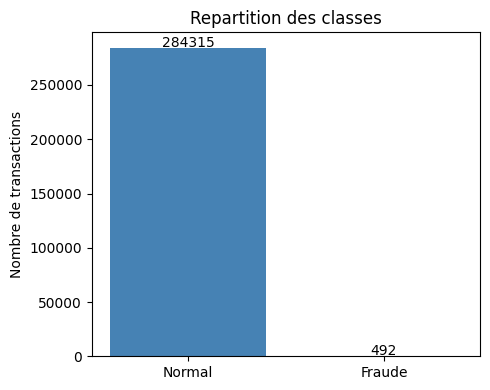

In [10]:
# visualisation de la distribution des classes
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Normal', 'Fraude'], [counts[0], counts[1]], color=['steelblue', 'tomato'])
ax.set_title('Repartition des classes')
ax.set_ylabel('Nombre de transactions')
for i, v in enumerate([counts[0], counts[1]]):
    ax.text(i, v + 1000, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [11]:
# verification des valeurs manquantes
missing = df.isnull().sum()
print('Valeurs manquantes par colonne :')
print(missing[missing > 0] if missing.sum() > 0 else 'Aucune valeur manquante.')

Valeurs manquantes par colonne :
Aucune valeur manquante.


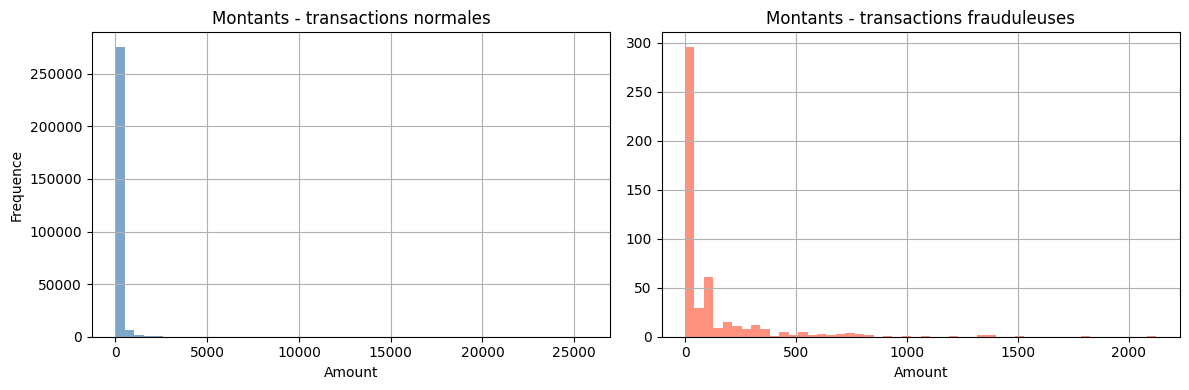

Montant moyen fraudes : 122.21
Montant moyen normales : 88.29


In [12]:
# distribution de Amount selon la classe
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['Class'] == 0]['Amount'].hist(bins=50, ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title('Montants - transactions normales')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequence')

df[df['Class'] == 1]['Amount'].hist(bins=50, ax=axes[1], color='tomato', alpha=0.7)
axes[1].set_title('Montants - transactions frauduleuses')
axes[1].set_xlabel('Amount')

plt.tight_layout()
plt.show()

# quelques statistiques utiles
print('Montant moyen fraudes :', round(df[df['Class']==1]['Amount'].mean(), 2))
print('Montant moyen normales :', round(df[df['Class']==0]['Amount'].mean(), 2))

In [13]:
from sklearn.preprocessing import StandardScaler

df_clean = df.copy()

scaler = StandardScaler()
df_clean['Amount_scaled'] = scaler.fit_transform(df_clean[['Amount']])
df_clean['Time_scaled']   = scaler.fit_transform(df_clean[['Time']])

# on retire les colonnes originales
df_clean.drop(columns=['Amount', 'Time'], inplace=True)

print('Shape apres nettoyage :', df_clean.shape)
df_clean.head(3)

Shape apres nettoyage : (284807, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Time_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562


In [14]:
from sklearn.model_selection import train_test_split

X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

# premier split : on isole le test set definitif
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# second split : train et validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
    # 0.176 de 85% = environ 15% du total
)

print('Train :', X_train.shape, '| fraudes :', y_train.sum())
print('Val   :', X_val.shape,   '| fraudes :', y_val.sum())
print('Test  :', X_test.shape,  '| fraudes :', y_test.sum())

Train : (199478, 30) | fraudes : 344
Val   : (42607, 30) | fraudes : 74
Test  : (42722, 30) | fraudes : 74


In [15]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Avant SMOTE - fraudes :', y_train.sum(), '/ total :', len(y_train))
print('Apres SMOTE - fraudes :', y_train_sm.sum(), '/ total :', len(y_train_sm))

Avant SMOTE - fraudes : 344 / total : 199478
Apres SMOTE - fraudes : 199134 / total : 398268


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report

modeles = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(
                               n_estimators=300,
                               max_depth=5,
                               learning_rate=0.05,
                               scale_pos_weight=1,
                               use_label_encoder=False,
                               eval_metric='logloss',
                               random_state=42,
                               verbosity=0
                           )
}

resultats = {}

for nom, modele in modeles.items():
    modele.fit(X_train_sm, y_train_sm)
    proba_val = modele.predict_proba(X_val)[:, 1]
    pred_val  = (proba_val >= 0.5).astype(int)
    auroc = roc_auc_score(y_val, proba_val)
    f1    = f1_score(y_val, pred_val)
    resultats[nom] = {'AUROC': round(auroc, 4), 'F1': round(f1, 4)}
    print(f'{nom:25s} -> AUROC: {auroc:.4f}  F1: {f1:.4f}')

Logistic Regression       -> AUROC: 0.9817  F1: 0.1202
Random Forest             -> AUROC: 0.9815  F1: 0.8611
XGBoost                   -> AUROC: 0.9786  F1: 0.5455


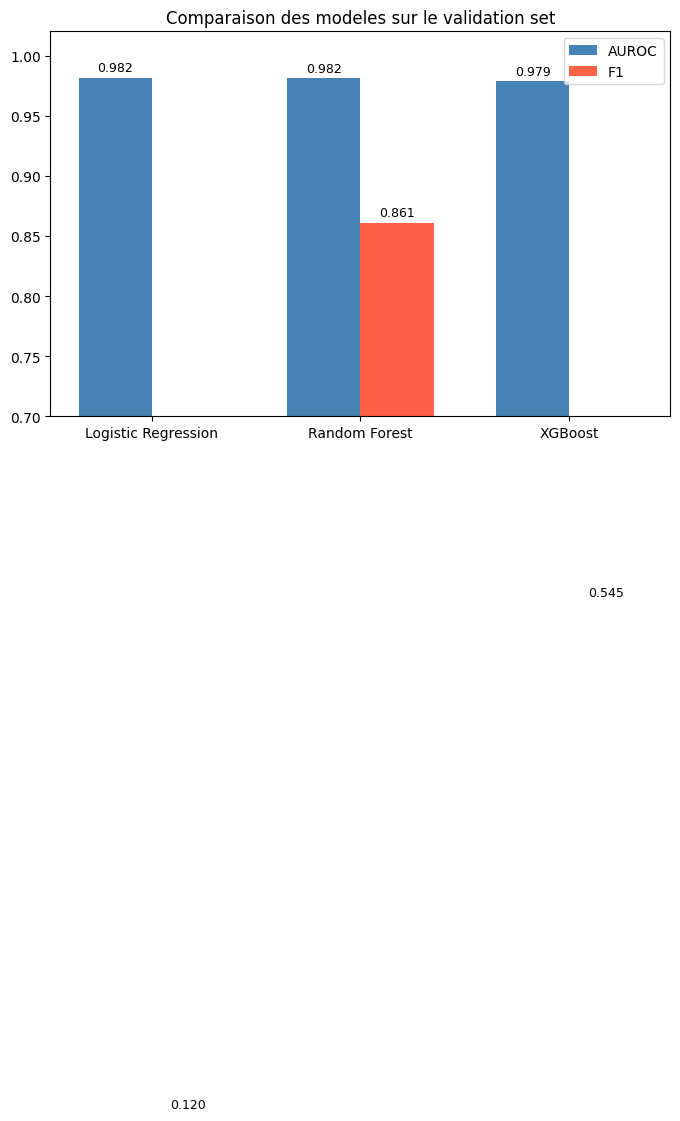

In [17]:
# visualisation comparative
noms   = list(resultats.keys())
aurocs = [resultats[n]['AUROC'] for n in noms]
f1s    = [resultats[n]['F1']    for n in noms]

x = np.arange(len(noms))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, aurocs, width, label='AUROC', color='steelblue')
bars2 = ax.bar(x + width/2, f1s,    width, label='F1',    color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(noms)
ax.set_ylim(0.7, 1.02)
ax.set_title('Comparaison des modeles sur le validation set')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators':  [200, 300]
}

xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

grid_search = GridSearchCV(
    xgb_base,
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_sm, y_train_sm)

print('Meilleurs hyperparametres :', grid_search.best_params_)
print('Meilleur AUROC CV :', round(grid_search.best_score_, 4))

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Meilleurs hyperparametres : {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
Meilleur AUROC CV : 1.0


In [19]:
# on recupere le meilleur modele
best_xgb = grid_search.best_estimator_

proba_val  = best_xgb.predict_proba(X_val)[:, 1]
pred_val   = (proba_val >= 0.5).astype(int)

print('AUROC val apres tuning :', round(roc_auc_score(y_val, proba_val), 4))
print('F1 val apres tuning    :', round(f1_score(y_val, pred_val), 4))

AUROC val apres tuning : 0.9785
F1 val apres tuning    : 0.7975


Seuil optimal : 0.991
F1 au seuil optimal : 0.8714


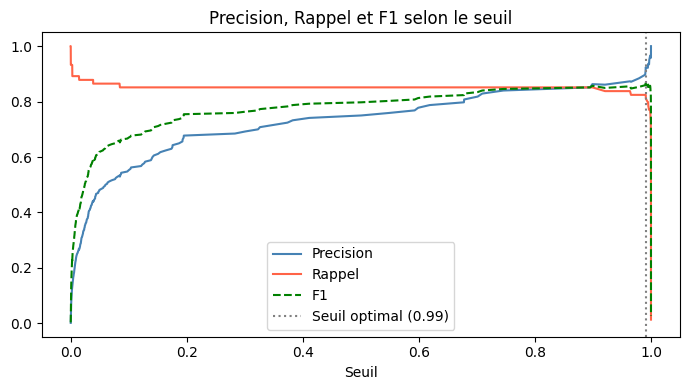

In [20]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_val, proba_val)

# on cherche le seuil qui maximise le F1
f1_scores_seuils = 2 * precision * recall / (precision + recall + 1e-8)
idx_best = np.argmax(f1_scores_seuils)
seuil_optimal = thresholds[idx_best]

print('Seuil optimal :', round(seuil_optimal, 3))
print('F1 au seuil optimal :', round(f1_scores_seuils[idx_best], 4))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, precision[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recall[:-1],    label='Rappel',    color='tomato')
ax.plot(thresholds, f1_scores_seuils[:-1], label='F1', color='green', linestyle='--')
ax.axvline(x=seuil_optimal, color='gray', linestyle=':', label=f'Seuil optimal ({seuil_optimal:.2f})')
ax.set_xlabel('Seuil')
ax.set_title('Precision, Rappel et F1 selon le seuil')
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

proba_test = best_xgb.predict_proba(X_test)[:, 1]
pred_test  = (proba_test >= seuil_optimal).astype(int)

auroc_test = roc_auc_score(y_test, proba_test)
f1_test    = f1_score(y_test, pred_test)

print('=== Resultats sur le test set ===')
print(f'AUROC : {auroc_test:.4f}')
print(f'F1    : {f1_test:.4f}')
print()
print(classification_report(y_test, pred_test, target_names=['Normal', 'Fraude']))

=== Resultats sur le test set ===
AUROC : 0.9777
F1    : 0.8333

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     42648
      Fraude       0.95      0.74      0.83        74

    accuracy                           1.00     42722
   macro avg       0.97      0.87      0.92     42722
weighted avg       1.00      1.00      1.00     42722



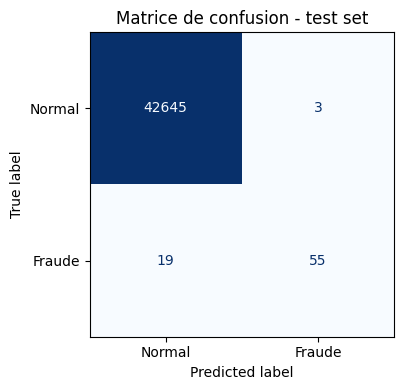

In [22]:
# matrice de confusion
cm = confusion_matrix(y_test, pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraude'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matrice de confusion - test set')
plt.tight_layout()
plt.show()

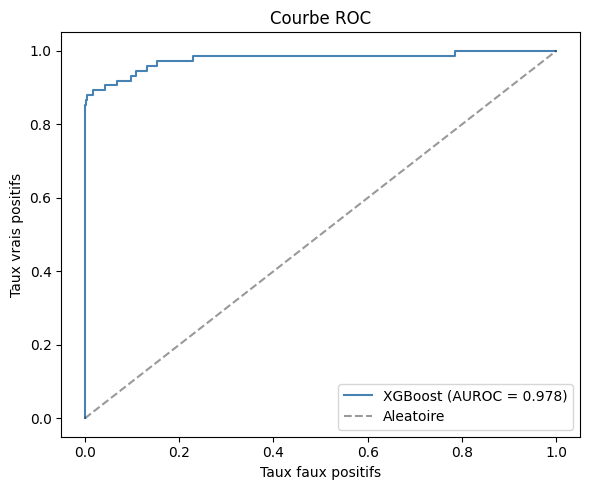

In [23]:
# courbe ROC
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, proba_test)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', label=f'XGBoost (AUROC = {auroc_test:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatoire')
ax.set_xlabel('Taux faux positifs')
ax.set_ylabel('Taux vrais positifs')
ax.set_title('Courbe ROC')
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
X_test_copy = X_test.copy()
X_test_copy['y_true']  = y_test.values
X_test_copy['y_pred']  = pred_test
X_test_copy['proba']   = proba_test

faux_positifs = X_test_copy[(X_test_copy['y_true'] == 0) & (X_test_copy['y_pred'] == 1)]
faux_negatifs = X_test_copy[(X_test_copy['y_true'] == 1) & (X_test_copy['y_pred'] == 0)]

print('Faux positifs (normales classees fraude) :', len(faux_positifs))
print('Faux negatifs (fraudes ratees)            :', len(faux_negatifs))

Faux positifs (normales classees fraude) : 3
Faux negatifs (fraudes ratees)            : 19


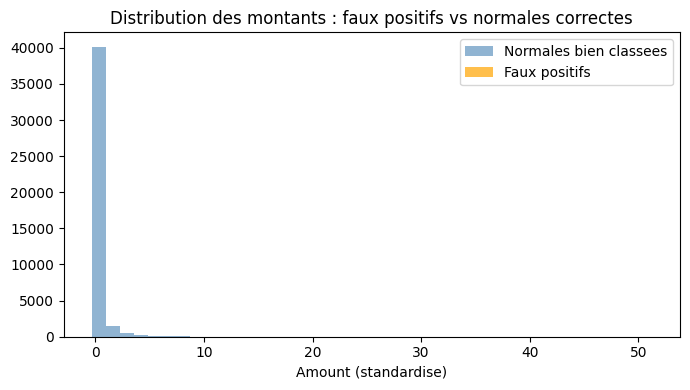

Montant moyen faux positifs       : -0.351
Montant moyen normales correctes  : 0.002


In [25]:
# les faux positifs ont-ils des montants particuliers ?
normales_correctes = X_test_copy[(X_test_copy['y_true'] == 0) & (X_test_copy['y_pred'] == 0)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(normales_correctes['Amount_scaled'], bins=40, alpha=0.6, label='Normales bien classees', color='steelblue')
ax.hist(faux_positifs['Amount_scaled'],      bins=20, alpha=0.7, label='Faux positifs', color='orange')
ax.set_xlabel('Amount (standardise)')
ax.set_title('Distribution des montants : faux positifs vs normales correctes')
ax.legend()
plt.tight_layout()
plt.show()

# observation : les faux positifs ont tendance a avoir des montants plus eleves
print('Montant moyen faux positifs       :', round(faux_positifs['Amount_scaled'].mean(), 3))
print('Montant moyen normales correctes  :', round(normales_correctes['Amount_scaled'].mean(), 3))

In [26]:
import shap

# TreeExplainer est optimise pour les modeles bases sur des arbres
explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

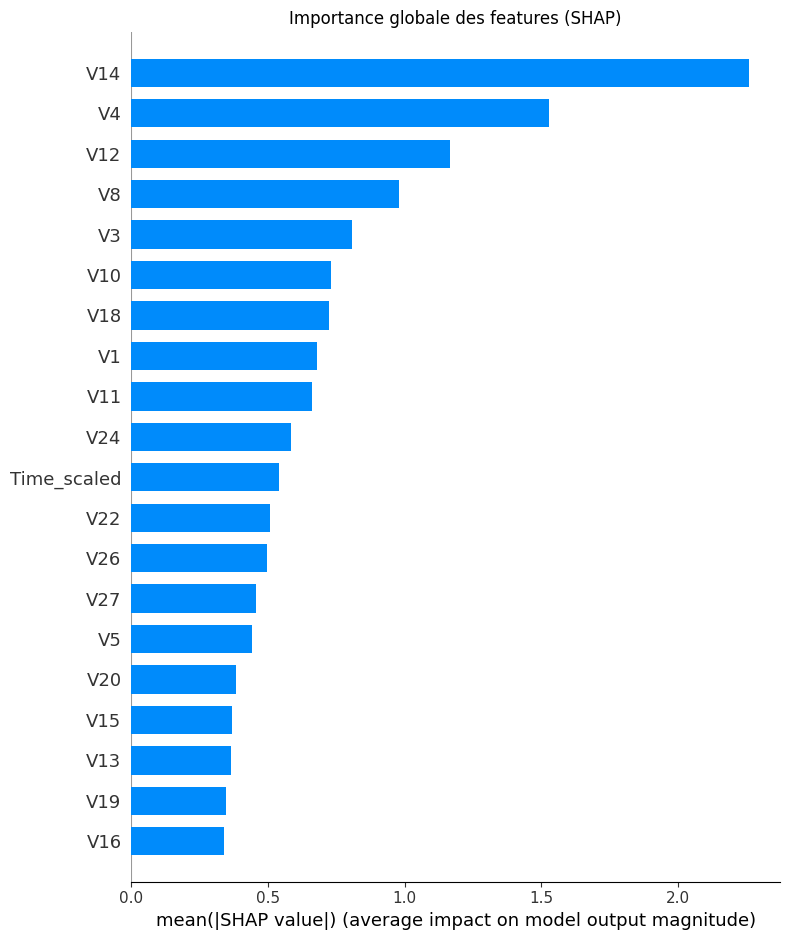

In [27]:
# importance globale des features
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Importance globale des features (SHAP)')
plt.tight_layout()
plt.show()

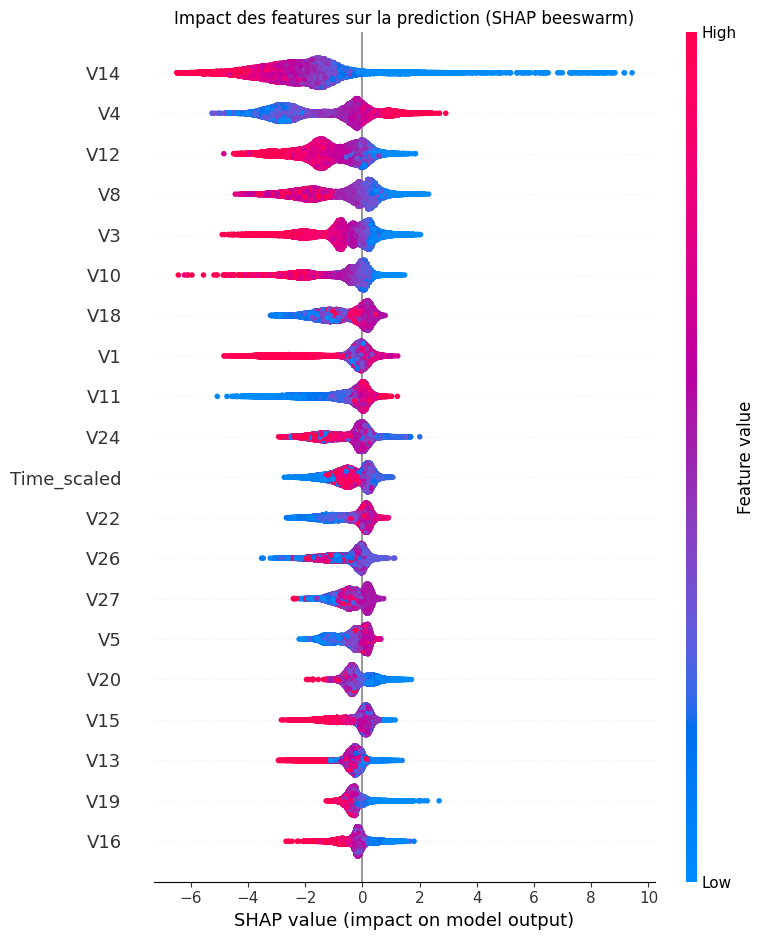

In [28]:
# beeswarm plot : montre la direction et l'intensite de chaque feature
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('Impact des features sur la prediction (SHAP beeswarm)')
plt.tight_layout()
plt.show()

Transaction index 182992 : fraude non detectee
Probabilite de fraude predite : 0.016



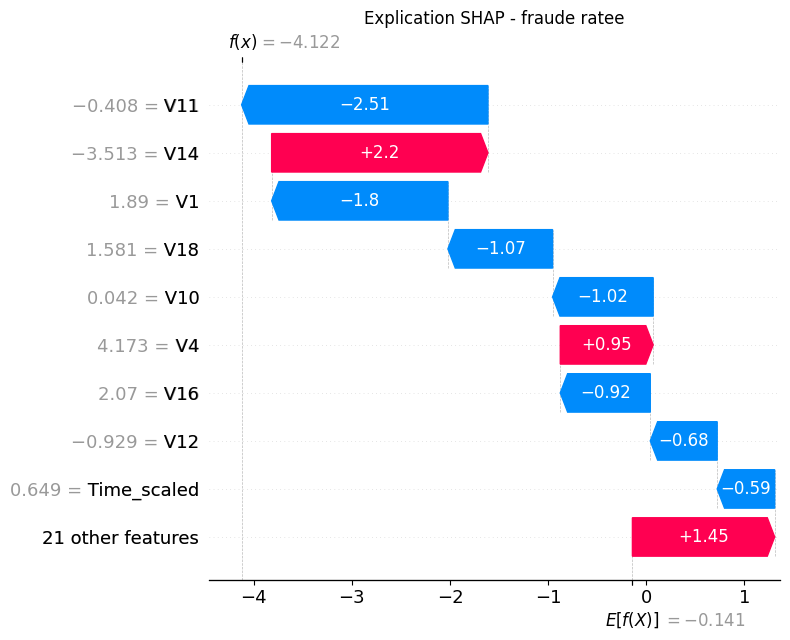

In [29]:
# explication d'une transaction specifique
# on prend un faux negatif (fraude ratee) pour comprendre pourquoi le modele a rate
if len(faux_negatifs) > 0:
    idx_exemple = faux_negatifs.index[0]
    # on retrouve la position dans X_test
    pos = list(X_test.index).index(idx_exemple)

    print(f'Transaction index {idx_exemple} : fraude non detectee')
    print(f'Probabilite de fraude predite : {proba_test[pos]:.3f}')
    print()

    shap.waterfall_plot(
        shap.Explanation(
            values      = shap_values[pos],
            base_values = explainer.expected_value,
            data        = X_test.iloc[pos],
            feature_names = X_test.columns.tolist()
        ),
        show=False
    )
    plt.title('Explication SHAP - fraude ratee')
    plt.tight_layout()
    plt.show()

In [30]:
import joblib
import json
import os

os.makedirs('outputs', exist_ok=True)

# sauvegarde du modele
joblib.dump(best_xgb, 'outputs/best_model.pkl')
joblib.dump(scaler,   'outputs/scaler.pkl')

# on enregistre aussi les metriques finales
metriques = {
    'auroc_test': round(auroc_test, 4),
    'f1_test':    round(f1_test, 4),
    'seuil':      round(float(seuil_optimal), 3),
    'best_params': grid_search.best_params_
}

with open('outputs/metriques.json', 'w') as f:
    json.dump(metriques, f, indent=2)

print('Modele sauvegarde dans outputs/best_model.pkl')
print('Metriques :', metriques)

Modele sauvegarde dans outputs/best_model.pkl
Metriques : {'auroc_test': np.float64(0.9777), 'f1_test': 0.8333, 'seuil': 0.991, 'best_params': {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}}


In [32]:
import mlflow
mlflow.set_experiment("fraud_xgb_v1")
with mlflow.start_run(run_name="fraud_xgb_grid_v1"):
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("auroc_test", auroc_test)
    mlflow.log_metric("f1_test", f1_test)
    mlflow.log_metric("seuil", float(seuil_optimal))
    print("Run ID :", mlflow.active_run().info.run_id)

Run ID : 69d69874f0ba44fdb1292a6290c1ff49
